In [1]:
import wrds
db = wrds.Connection(wrds_username='你的用户名')
db.list_libraries()                     
db.list_tables('comp')                  
db.describe_table('comp', 'funda')      

Enter your WRDS username [你的用户名]: cocof
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Approximately 937210 rows in comp.funda.


,name,nullable,type,comment
0,gvkey,True,VARCHAR(7),Global Company Key
1,datadate,True,DATE,Data Date
2,fyear,True,INTEGER,Data Year - Fiscal
3,indfmt,True,VARCHAR(13),Industry Format
4,consol,True,VARCHAR(3),Level of Consolidation - Company Annual Descri...
...,...,...,...,...
944,au,True,VARCHAR(9),Auditor
945,auop,True,VARCHAR(9),Auditor Opinion
946,auopic,True,VARCHAR(2),Auditor Opinion - Internal Control
947,ceoso,True,VARCHAR(2),Chief Executive Officer SOX Certification


In [10]:
sql_simple = """
SELECT tic, fyear, sale
FROM comp.funda
WHERE tic = 'AAPL'
LIMIT 5
"""
df_simple = db.raw_sql(sql_simple)

In [12]:
print("=== SQL RESULT===")
df_simple

=== SQL RESULT===


,tic,fyear,sale
0,AAPL,2013,170910.0
1,AAPL,2013,<NA>
2,AAPL,1980,117.126
3,AAPL,1981,334.783
4,AAPL,1982,583.061


In [13]:
print("\n=== Data Types ===")
print(df_simple.dtypes)



=== Data Types ===
tic      string[python]
fyear             Int64
sale            Float64
dtype: object


In [16]:
df_simple.to_excel("aapl_sales_sample.xlsx", index=False)
print("Exported to aapl_sales_sample.xlsx")


Exported to aapl_sales_sample.xlsx


In [17]:
ticker = "AAPL"
start_year = 2020

sql_param = f"""
SELECT gvkey, tic, fyear, sale, ni, at, seq
FROM comp.funda
WHERE tic = '{ticker}'
  AND fyear >= {start_year}
ORDER BY fyear
"""

print(f"\n=== Generated SQL ===\n{sql_param}")

df_aapl = db.raw_sql(sql_param)
print(f"\n=== Retrieved {len(df_aapl)} rows ===")
df_aapl.head()


=== Generated SQL ===

SELECT gvkey, tic, fyear, sale, ni, at, seq
FROM comp.funda
WHERE tic = 'AAPL'
  AND fyear >= 2020
ORDER BY fyear


=== Retrieved 12 rows ===


,gvkey,tic,fyear,sale,ni,at,seq
0,001690,AAPL,2020,274515.0,57411.0,323888.0,65339.0
1,001690,AAPL,2020,274515.0,57411.0,323888.0,65339.0
2,001690,AAPL,2021,365817.0,94680.0,351002.0,63090.0
3,001690,AAPL,2021,365817.0,94680.0,351002.0,63090.0
4,001690,AAPL,2022,394328.0,99803.0,352755.0,50672.0


In [18]:
df_aapl['profit_margin'] = df_aapl['ni'] / df_aapl['sale']
df_aapl['asset_turnover'] = df_aapl['sale'] / df_aapl['at']
df_aapl['equity_multiplier'] = df_aapl['at'] / df_aapl['seq']
df_aapl['ROE'] = df_aapl['profit_margin'] * df_aapl['asset_turnover'] * df_aapl['equity_multiplier']

print("\n=== DuPont Analysis Results ===")
df_aapl[['fyear', 'profit_margin', 'asset_turnover', 'equity_multiplier', 'ROE']]



=== DuPont Analysis Results ===


,fyear,profit_margin,asset_turnover,equity_multiplier,ROE
0,2020,0.209136,0.847562,4.957039,0.878664
1,2020,0.209136,0.847562,4.957039,0.878664
2,2021,0.258818,1.042208,5.563512,1.500713
3,2021,0.258818,1.042208,5.563512,1.500713
4,2022,0.253096,1.117852,6.961537,1.969589
5,2022,0.253096,1.117852,6.961537,1.969589
6,2023,0.253062,1.087077,5.673462,1.56076
7,2023,0.253062,1.087077,5.673462,1.56076
8,2024,0.239713,1.071387,6.40878,1.645935
9,2024,0.239713,1.071387,6.40878,1.645935


In [19]:
df_aapl.to_excel("aapl_dupont_analysis.xlsx", index=False)
print("Exported to aapl_dupont_analysis.xlsx")


Exported to aapl_dupont_analysis.xlsx


Matplotlib is building the font cache; this may take a moment.


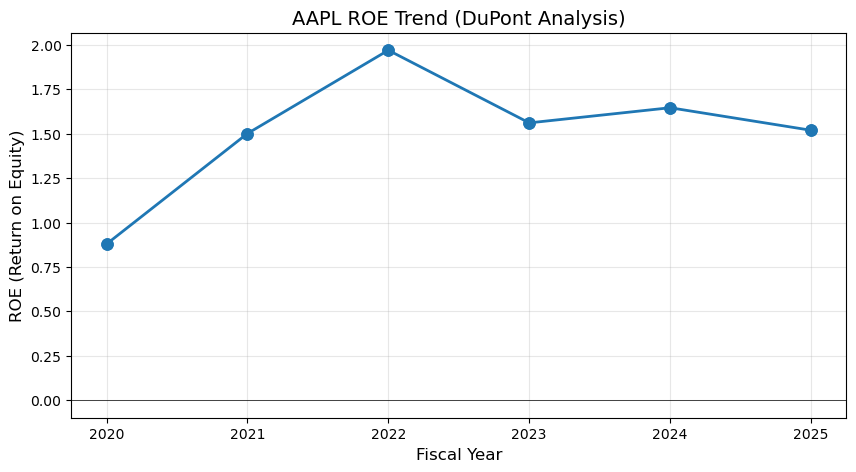

Saved chart to roe_trend.png


In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(df_aapl['fyear'], df_aapl['ROE'], marker='o', linewidth=2, markersize=8)
plt.title(f'{ticker} ROE Trend (DuPont Analysis)', fontsize=14)
plt.xlabel('Fiscal Year', fontsize=12)
plt.ylabel('ROE (Return on Equity)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.savefig('roe_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved chart to roe_trend.png")


In [24]:
companies = [('AAPL', 'Apple'), ('MSFT', 'Microsoft'), ('GOOGL', 'Google')]
all_data = []

for tick, name in companies:
    sql = f"""
    SELECT tic, fyear, sale, ni, at, seq
    FROM comp.funda
    WHERE tic = '{tick}'
      AND fyear >= 2020
    ORDER BY fyear
    """
    df_temp = db.raw_sql(sql)
    
    df_temp['profit_margin'] = df_temp['ni'] / df_temp['sale']
    df_temp['asset_turnover'] = df_temp['sale'] / df_temp['at']
    df_temp['equity_multiplier'] = df_temp['at'] / df_temp['seq']
    df_temp['ROE'] = df_temp['profit_margin'] * df_temp['asset_turnover'] * df_temp['equity_multiplier']
    df_temp['company'] = name
    all_data.append(df_temp)


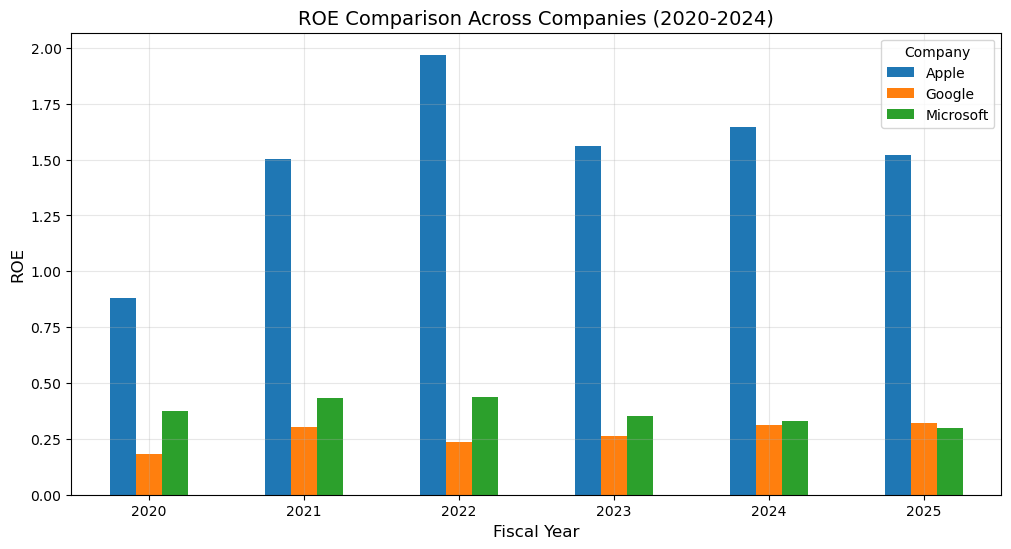

Saved chart to roe_comparison.png


In [26]:
import pandas as pd
import matplotlib.pyplot as plt 
df_compare = pd.concat(all_data)
df_compare = df_compare.drop_duplicates(subset=['fyear', 'company'], keep='first')
pivot_roe = df_compare.pivot(index='fyear', columns='company', values='ROE')
pivot_roe.plot(kind='bar', figsize=(12, 6))
plt.title('ROE Comparison Across Companies (2020-2024)', fontsize=14)
plt.ylabel('ROE', fontsize=12)
plt.xlabel('Fiscal Year', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Company')
plt.grid(True, alpha=0.3)
plt.savefig('roe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved chart to roe_comparison.png")

In [27]:
print("\n=== ROE Comparison Table ===")
print(pivot_roe)



=== ROE Comparison Table ===
company     Apple    Google  Microsoft
fyear                                 
2020     0.878664  0.180948   0.374298
2021     1.500713  0.302156   0.431522
2022     1.969589  0.234134   0.436755
2023      1.56076  0.262542   0.350887
2024     1.645935  0.310941   0.328281
2025      1.51913  0.320252   0.296472


In [28]:
pivot_roe.to_excel("roe_comparison.xlsx")
print("Exported to roe_comparison.xlsx")

Exported to roe_comparison.xlsx


In [29]:
db.close()
print("WRDS connection closed")

WRDS connection closed
